# Loan Approval Prediction Using Machine Learning

## Project Overview

This project aims to predict whether a loan application should be approved or rejected based on applicant-related and financial attributes using Support Vector Machine (SVM) algorithm.

### Problem Statement
- **Task**: Binary Classification (Approved/Rejected)
- **Algorithm**: Support Vector Machine (SVM)
- **Dataset**: Loan Application Dataset with 20,000 records

### Project Structure
1. Data Loading and Exploration
2. Data Preprocessing and Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Model Training (SVM)
6. Model Evaluation
7. Results and Insights

---

## 1. Import Required Libraries

In [2]:
%pip install seaborn
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Machine Learning - Model
from sklearn.svm import SVC

# Machine Learning - Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ All libraries imported successfully!")


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
✓ All libraries imported successfully!


## 2. Load and Explore the Dataset

In [3]:
# Load the dataset
df = pd.read_csv('loan_dataset_20000.csv')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Dataset loaded successfully!
Dataset shape: (20000, 22)
Number of records: 20000
Number of features: 22


In [4]:
# Display first few rows
print("\n=== First 5 rows of the dataset ===")
df.head()


=== First 5 rows of the dataset ===


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,interest_rate,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,Car,13.39,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,Debt consolidation,17.81,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,Business,9.53,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,Other,7.99,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,Car,15.20,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [5]:
# Display dataset information
print("\n=== Dataset Information ===")
df.info()


=== Dataset Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  obj

In [6]:
# Statistical summary
print("\n=== Statistical Summary ===")
df.describe()


=== Statistical Summary ===


,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637766,3629.136466,0.177019,679.25695,15129.300909,12.400626,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [7]:
# Check for missing values
print("\n=== Missing Values Analysis ===")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(
    by='Missing Values', ascending=False
)

if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found in the dataset!")


=== Missing Values Analysis ===
No missing values found in the dataset!


In [8]:
# Check for duplicate records
duplicates = df.duplicated().sum()
print(f"\n=== Duplicate Records ===")
print(f"Number of duplicate records: {duplicates}")


=== Duplicate Records ===
Number of duplicate records: 0


## 3. Exploratory Data Analysis (EDA)

In [9]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")

Categorical columns (6): ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

Numerical columns (16): ['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies', 'loan_paid_back']


In [10]:
# Target variable distribution
if 'Loan_Status' in df.columns:
    target_col = 'Loan_Status'
elif 'loan_status' in df.columns:
    target_col = 'loan_status'
else:
    # Find the target column
    target_col = [col for col in df.columns if 'status' in col.lower()]
    target_col = target_col[0] if target_col else df.columns[-1]
    print(f"\n=== Target Variable: {target_col} ===")
print(df[target_col].value_counts())
print(f"\nPercentage Distribution:")
print(df[target_col].value_counts(normalize=True) * 100)


=== Target Variable: marital_status ===
marital_status
Single      9031
Married     8974
Divorced    1428
Widowed      567
Name: count, dtype: int64

Percentage Distribution:
marital_status
Single      45.155
Married     44.870
Divorced     7.140
Widowed      2.835
Name: proportion, dtype: float64


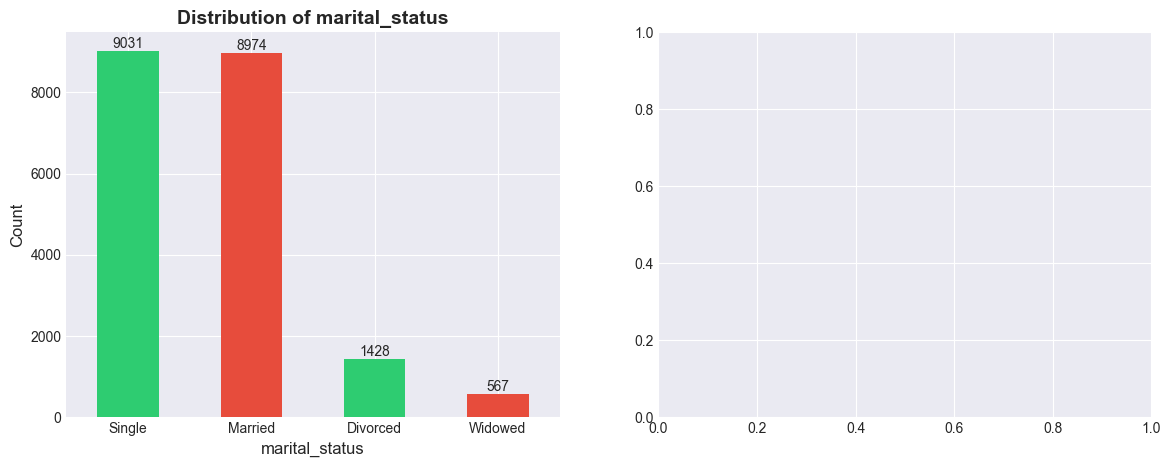

In [11]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Count plot
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title(f'Distribution of {target_col}', fontsize=14, fontweight='bold')
axes[0].set_xlabel(target_col, fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

# Add value labels on bars
for container in axes[0].containers:
    axes[0].bar_label(container)
